# 第 01a 课:对称性、等变性与几何神经网络

**你将学到**

- 为什么对称性是原子体系机器学习的核心设计原则。
- 欧几里得群 $E(3)$ 及其子群 $SE(3)$、$O(3)$、$SO(3)$ 各自包含什么。
- **不变性(invariance)**与**等变性(equivariance)**的严格定义,以及物理实例(能量是不变的;力和偶极矩是等变的)。
- 一个数值演示:普通的机器学习原子间势(MLIP)**并不**具备不变性,而数据增强只能*近似*对称性,永远无法精确地施加对称性。

**先修要求:** 线性代数基础和 PyTorch。

In [1]:
import sys
sys.path.insert(0, "..")  # Make course_utils importable

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3

from course_utils.plotting import scene3d, draw_point_cloud, show3d

torch.set_default_dtype(torch.float64)  # float64: separate symmetry breaking from round-off
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## 为什么对称性对原子体系机器学习至关重要

分子并不知晓我们为描述它所选取的坐标系。也就是说,如果我们

- 将每个原子**平移**同一个向量 $\vec{t}$,
- 用旋转矩阵 $R$ **旋转**整个体系,或
- 通过镜像平面**反射**它(等价地,先反演再旋转),

得到的原子位置*数值不同*,但*物理体系相同*。

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> <b>注意:</b> 反射较为微妙:它把分子映射为其镜像,对于手性分子而言,这确实产生了一个不同的对象。我们将在第 02a 课和第 06b 课中回到这个话题。 </div>

因此,物理可观测量在坐标系变换下必须以**规定的方式**变换。将原子位置写成 $x \in \mathbb{R}^{N\times 3}$ 的行,坐标系变换写为 $x_i \mapsto R\,x_i + \vec{t}$:

| 物理量 | 变换规则 | 行为 |
|---|---|---|
| 总能量 $E(x)$ | $E' = E$ | **不变的**(标量)|
| 原子 $i$ 受到的力 $\vec{F}_i = -\partial E/\partial \vec{x}_i$ | $\vec{F}_i' = R\,\vec{F}_i$ | **等变的**(向量)|
| 偶极矩 $\vec{\mu}$ | $\vec{\mu}' = R\,\vec{\mu}$ | **等变的**(向量)|
| 极化率 $\alpha$(3×3)| $\alpha' = R\,\alpha\,R^\top$ | **等变的**(二阶张量)|

实际意义在于:不遵守这些变换规则的模型,可能会对从不同角度观察的同一分子预测出不同的能量。当然,这样的预测*从构造上就是非物理的*。

这正是本课程主题背后的确切逻辑:构建内在具备正确变换行为的神经网络。

## 欧几里得群 $E(3)$ 及其子群

上述坐标系变换(平移、旋转和反射)构成一个**群**。群是一个带有复合法则 $G \times G \to G$ 的集合 $G$,满足

- (i) 存在单位元 $e$,使得 $ae = ea = a$,
- (ii) 复合满足结合律,
- (iii) 每个元素 $a$ 都有逆元 $a^{-1}$,满足 $a a^{-1} = a^{-1} a = e$。

**欧几里得群** $E(3)$ 是 $\mathbb{R}^3$ 上所有保距映射的集合。该群的每个元素都可以写成

$$ x \mapsto O\,x + \vec{t}, \qquad \qquad O \in O(3),\quad \text{and} \quad \vec{t} \in \mathbb{R}^3 , $$

其中 $O(3) = \{ O \in \mathbb{R}^{3\times 3} \mid O^\top O = \mathbb{1} \}$ 是**正交矩阵**构成的群:旋转($\det O = +1$)和旋转反射($\det O = -1$)。我们将频繁使用的子群总结在下表中:

| 群 | 内容 | 约束 |
|---|---|---|
| $SO(3)$ | 正常旋转 $R$ | $R^\top R = \mathbb{1}$,$\det R = +1$ |
| $O(3)$ | 旋转**和**反射/反演 | $O^\top O = \mathbb{1}$,$\det O = \pm 1$ |
| $SE(3)$ | 旋转 + 平移 | — |
| $E(3)$ | 旋转、反射、平移 | — |

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> <b>注意:</b> 反演操作

$$ P: \vec{x} \mapsto -\vec{x} $$

与每个旋转操作都对易,因此

$$ O(3) \;=\; SO(3) \times \{\mathbb{1}, P\}. $$

这意味着每个正交矩阵要么是一个旋转 $R$,要么是一个反演后的旋转 $PR = -R$。正是这种分解,使得 e3nn 包对我们为化学体系构建的每个特征都同时追踪一个旋转标签($l$)*和*一个宇称标签($e$/$o$)。我们将在第 01b 课和第 02a 课中回到这个话题。 </div>

让我们对旋转的若干群公理进行数值验证。我们将使用 `e3nn` 包生成随机旋转矩阵,并用 `torch` 计算行列式。

In [2]:
# Create two random elements of SO(3)
R1, R2 = o3.rand_matrix(), o3.rand_matrix()

# Create the identity matrix (3x3)
I = torch.eye(3)

# Check the group axioms for rotations
print(f"orthogonality  |R1^T R1 - 1| = {(R1.T @ R1 - I).abs().max():.2e}")
print(f"proper         det R1        = {torch.det(R1):+.15f}")
print(f"closure        det (R1 R2)   = {torch.det(R1 @ R2):+.15f}  (product is again a rotation)")
print(f"inverse        |R1 R1^T - 1| = {(R1 @ R1.T - I).abs().max():.2e}  (inverse = transpose)")

orthogonality  |R1^T R1 - 1| = 1.39e-17
proper         det R1        = +1.000000000000000
closure        det (R1 R2)   = +1.000000000000000  (product is again a rotation)
inverse        |R1 R1^T - 1| = 2.78e-17  (inverse = transpose)


现在,来检查非正常元素:反演 $P = -1$ 和旋转反射 $-R (\text{det} = -1)$

In [3]:
# parity / inversion
P = -I

# Checks
print(f"det P        = {torch.det(P):+.0f}")
print(f"det (P R1)   = {torch.det(P @ R1):+.15f}   <-- roto-reflection")
print(f"P commutes with rotations: |P R1 - R1 P| = {(P @ R1 - R1 @ P).abs().max():.1e}")
# ... so O(3) = SO(3) x {1, P}: every O in O(3) is R or -R for some rotation R.

det P        = -1
det (P R1)   = -1.000000000000000   <-- roto-reflection
P commutes with rotations: |P R1 - R1 P| = 0.0e+00


## 不变性 vs. 等变性:定义

对于群 $G$,函数 $f: X \to Y$ 在 $G$ 下是**等变的**,如果

$$ f\!\left(D_X(g)\,x\right) \;=\; D_Y(g)\, f(x) \qquad \qquad \forall\, g \in G,\quad \text{and} \quad \forall\, x \in X , $$

其中 $D_X(g)$ 和 $D_Y(g)$ 分别是群元素 $g$ 作用在向量空间 $X$ 和 $Y$ 上的表示。矩阵 $D_X(g)$ 和 $D_Y(g)$ 描述了数据*如何*随群操作变换。对称操作的矩阵表示将在第 01b 课中定义。眼下,你可以把 $D_X(g)$ 理解为"按 $g$ 旋转所有输入坐标 $x$ 的对象"。

现在,我们可以用简单的语言定义不变性和等变性:

- **不变性**是 $D_Y(g) = \mathbb{1}$(对所有 $g$)的特殊情形:变换后的输出完全不动。能量作为物理量的一个例子是不变的。当你旋转一个孤立分子(或从另一个角度看它)时,它的能量不应改变。
- **等变性**更一般:输出以自己规定的方式*随*输入一起变换。力和偶极矩是等变量,对应 $D_Y(g) = R$。

有两点原因使等变性成为为原子体系构建几何神经网络的正确工程工具:

1. **复合保持等变性**:若 $f$ 和 $h$ 是等变函数,则 $h(f(D(g)x)) = h(D(g)f(x)) = D(g)\,h(f(x))$。因此,由等变构件(层、特征等)构建的深度神经网络是端到端等变的。
2. **学到的权重是标量**:$f(w, D_X(g)x) = D_Y(g) f(w, x)$。也就是说,参数不参与变换。对称性约束的是架构,而不是训练循环。

让我们创建一个玩具体系——一团总电荷为零的 5 个点电荷——并为该体系定义两个度量函数:一个是严格不变的函数,计算点电荷之间成对距离之和;另一个是严格等变的函数,返回体系的偶极矩向量。然后,我们将数值地检验这两个函数的不变性和等变性。

In [4]:
# Create a system of fixed charges with zero net charge
q = torch.tensor([+1.0, +1.0, -0.5, -0.5, -1.0])

# Define a function that is invariant under rotations and translations
def f_inv(x):
    '''Sum of all pairwise distances of a point cloud x: (N, 3) -> scalar. Invariant.'''
    return torch.pdist(x).sum()

# Define a dipole moment function that is equivariant under rotations and
# translations
def f_dip(x):
    '''Dipole moment mu = sum_i q_i x_i : (N, 3) -> vector. Equivariant (needs sum q = 0
    for translation invariance -- just like a neutral molecule).'''
    return (q[:, None] * x).sum(dim=0)

# The coordinates of the point charges
x = torch.randn(5, 3)

# The translation vector
t = torch.randn(3)

# The rotation matrix
R = o3.rand_matrix()

# Transform the charge cloud with g.x = R x + t
gx = x @ R.T + t

# Check invariance and equivariance
print(f"invariance    |E(g.x) - E(x)|        = {(f_inv(gx) - f_inv(x)).abs():.2e}")
print(f"equivariance  |mu(g.x) - R mu(x)|    = {(f_dip(gx) - R @ f_dip(x)).abs().max():.2e}")
print(f"but NOT invariant: |mu(g.x) - mu(x)| = {(f_dip(gx) - f_dip(x)).abs().max():.2e}")

invariance    |E(g.x) - E(x)|        = 0.00e+00
equivariance  |mu(g.x) - R mu(x)|    = 2.22e-16
but NOT invariant: |mu(g.x) - mu(x)| = 2.18e+00


两个恒等式都在 $\approx 10^{-15}$(float64 舍入误差)精度内成立。数值上,这就是"精确对称性"的样子。这个数值精度标准将贯穿本课程中我们构建的每个网络的每一层。我们在 [course_utils](../course_utils) 文件夹中创建了辅助函数(例如 `course_utils.equivariance.assert_equivariant`),从第 02a 课起用它们来强制执行这一标准。

除了数值验证之外,直观地看一看我们的点电荷玩具体系也很有益。下面展示了我们的点云及其旋转和反射后的副本。

In [5]:
# A chiral 4-point charge cloud
x0 = torch.tensor([[0.0, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 0]])

# Center the system to remove translation
x0 = x0 - x0.mean(dim=0)

# Create a random rotation matrix to rotate the point-charge cloud
R_show = o3.rand_matrix()

# Plot the original, rotated, and inverted clouds -- drag to rotate, scroll to zoom
fig = scene3d()
draw_point_cloud(x0, fig=fig, color="C0", label="original  x")
draw_point_cloud(x0 @ R_show.T, fig=fig, color="C1", label="rotated  Rx")
draw_point_cloud(-x0, fig=fig, color="C2", label="inverted  Px = -x")
show3d(fig, title="Original, rotated, and inverted point-charge clouds")

<plotly figure: Original, rotated, and inverted point-charge clouds>

旋转后的体系(橙色)与原体系(蓝色)是同一个物理对象。反射后的版本(绿色)是原体系的镜像。请随意旋转交互式 3D 图,从不同角度观察这些点云。

## 普通多层感知机不是不变的

将点云的展平坐标 $x \in \mathbb{R}^{N \times 3}$ 输入一个普通的多层感知机 $f_\theta: \mathbb{R}^{3N} \to \mathbb{R}$。架构中没有任何东西将感知机对原电荷云的输出 $f_\theta(x)$ 与对旋转后电荷云的输出 $f_\theta(Rx)$ 联系起来。换句话说,这两个输出只是一个任意光滑函数在 $\mathbb{R}^{3N}$ 中两个不相关点上的取值。

In [6]:
# Create a simple multi-layer perceptron (MLP) that takes flattened coordinates
# of a point cloud as input and outputs a scalar value.
def make_mlp(n_in, hidden=64):
    return torch.nn.Sequential(
        torch.nn.Linear(n_in, hidden),
        torch.nn.SiLU(),
        torch.nn.Linear(hidden, hidden),
        torch.nn.SiLU(),
        torch.nn.Linear(hidden, 1),
    )


# Create a random point cloud of N=5 points in 3D space and evaluate the output
# of the MLP for the original point cloud
N = 5
mlp = make_mlp(3 * N)
print(f"The number of parameters in the MLP: {sum(p.numel() for p in mlp.parameters())}")

# Create random coordinates for the 3D point cloud
x = torch.randn(N, 3)

# Evaluate the output of MLP for 256 random rotations of the point cloud and
# compute the mean, standard deviation, and spread of the outputs
preds = torch.stack([mlp((x @ o3.rand_matrix().T).flatten()) for _ in range(256)])
print(f"f(x) = {mlp(x.flatten()).item():+.4f}")
print(
    f"f(Rx) over 256 random rotations: mean {preds.mean():+.4f}, "
    f"std {preds.std():.4f}, spread {preds.max() - preds.min():.4f}"
)

The number of parameters in the MLP: 5249
f(x) = -0.1171
f(Rx) over 256 random rotations: mean -0.1249, std 0.0492, spread 0.2386


如你所见,第三行显示:当我们*只是从不同角度观察同一团电荷云*时,MLP 的预测值就在很大的范围内游走。如果 $f_\theta$ 是一个原子间能量,那么旋转一个分子就会改变其预测能量,而由此导出的力会包含本不该存在的作用于整个分子的力矩。

## 数据增强只能*近似*对称性

缓解上述问题影响的一种方法是**数据增强**:在输入数据的随机旋转副本上训练,并期望网络学会不变性。

让我们测量数据增强在实践中到底有多有效。我们尝试构建一个回归模型,其目标性质是严格不变的——输入坐标的成对距离之和:

$$ y(x) \;=\; \sum_{i<j} \left\lVert \vec{x}_i - \vec{x}_j \right\rVert , $$

(成对距离之和——可以把它粗略类比为势能),共三个模型:

| 模型 | 输入 | 对称性策略 |
|---|---|---|
| **A. MLP** | 展平坐标 $\in \mathbb{R}^{15}$ | 无 |
| **B. MLP + 数据增强** | 展平坐标,每步重新随机旋转 | 学习得到的(近似的)|
| **C. 不变特征** | 10 个成对距离 | **构造上严格不变** |

我们报告在*旋转后*点云上的测试 RMSE,以及在随机旋转下的**不变性误差** $\max_R \lvert f(Rx) - f(x)\rvert$。我们的数据集由 5 个高斯点电荷云组成,以模拟分子中单个电子的弥散电荷云。训练和测试分别使用 512 和 128 个点云样本。

In [7]:
# Target = sum of pairwise distances
def target(x_batch):
    # (B, N, 3) -> (B,)
    return torch.stack([torch.pdist(x).sum() for x in x_batch])


def dists(x_batch):
    # 5 points in 3D space have 10 pairwise distances (N(N-1)/2 = 5x4/2 = 10)
    # invariant features: (B, N, 3) -> (B, 10)
    return torch.stack([torch.pdist(x) for x in x_batch])


# Set the random seed for reproducibility
torch.manual_seed(1)

# Dataset: clouds of N=5 Gaussian points;
x_train, x_test = torch.randn(512, N, 3), torch.randn(128, N, 3)
y_train, y_test = target(x_train), target(x_test)
print(
    f"train {tuple(x_train.shape)},\ntest  {tuple(x_test.shape)},\n"
    f"target mean {y_train.mean():.2f} +/- {y_train.std():.2f}"
)

train (512, 5, 3),
test  (128, 5, 3),
target mean 22.32 +/- 4.51


让我们创建一个训练循环,它返回一个训练好的模型用于测试。

In [8]:
# Create the training loop. Yields trained a model for testing
def train(model, features, augment=False, steps=400, lr=1e-2, seed=2):
    """Full-batch Adam on (x_train, y_train). features: maps (B, N, 3) -> model input.
    augment=True: draw a fresh random rotation per sample at every step."""
    
    # Set the random seed for reproducibility
    torch.manual_seed(seed)
    
    # Create an Adam optimizer for the model parameters with the specified learning rate
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop for the specified number of steps
    for _ in range(steps):
        opt.zero_grad()
        xb = x_train
        if augment:
            # (B, 3, 3), one rotation per cloud
            Rb = o3.rand_matrix(len(xb))
            
            # x_i -> R x_i (target is unchanged)
            xb = torch.einsum("bij,bnj->bni", Rb, xb)
        
        # Compute the loss as the mean squared error between the model
        # predictions and the true targets
        loss = ((model(features(xb)).squeeze(-1) - y_train) ** 2).mean()
        
        # Backpropagate the loss
        loss.backward()
        
        # Update the model parameters
        opt.step()
    return model

我们现在使用上面定义的 `train` 函数来训练这三个模型。

In [9]:

# Flatten the point cloud coordinates to feed into the MLP- 5 point clouds with
# 3 (x,y,z) coordinates each (B, N, 3) -> (B, 15)
flat = lambda xb: xb.flatten(1)

# Train plain MLP
model_A = train(make_mlp(3 * N), flat, steps=500)

# Train augmented MLP
model_B = train(make_mlp(3 * N), flat, augment=True, steps=500)

# Train using invariant features (pairwise distances)
model_C = train(make_mlp(10), dists, steps=500)

print("training done")

training done


模型已训练完毕。现在评估它们在测试集上的表现。

In [10]:
@torch.no_grad()
def evaluate(model, features, n_rot=64):
    """Test RMSE on rotated clouds + invariance error max_R |f(Rx) - f(x)|."""
    
    # Evaluate the model on the test set without any rotations to get the
    # baseline predictions
    f0 = model(features(x_test)).squeeze(-1)
    
    # Initialize the invariance error and a list to store the RMSE for each rotation
    inv_err, rot_rmse = 0.0, []
    
    # Note that we are rotating the test clouds here to evaluate the
    # invariance capability of the model
    for _ in range(n_rot):
        
        # Generate a random rotation matrix for each point cloud in the test set
        Rb = o3.rand_matrix(len(x_test))
        
        # Predict the output of the model for the rotated point clouds
        fR = model(features(torch.einsum("bij,bnj->bni", Rb, x_test))).squeeze(-1)
        
        # Guard against numerical round-off errors using max()
        inv_err = max(inv_err, (fR - f0).abs().max().item())
        
        # Compute the root mean square error (RMSE) for the rotated predictions
        rot_rmse.append(((fR - y_test) ** 2).mean())
    return torch.stack(rot_rmse).mean().sqrt().item(), inv_err

# Evaluate the three models on the test set and print the results
results = {
    "A: MLP": evaluate(model_A, flat),
    "B: MLP + rot. aug.": evaluate(model_B, flat),
    "C: invariant feats": evaluate(model_C, dists),
}

# Print the results in a formatted table
print(f"{'Model':<22}{'Test RMSE (rotated)':>22}{'Invariance Error':>20}")
for name, (rmse, inv) in results.items():
    print(f"{name:<22}{rmse:>22.4f}{inv:>20.3e}")

Model                    Test RMSE (rotated)    Invariance Error
A: MLP                                0.9479           4.727e+00
B: MLP + rot. aug.                    0.7999           3.427e+00
C: invariant feats                    0.0475           1.421e-14


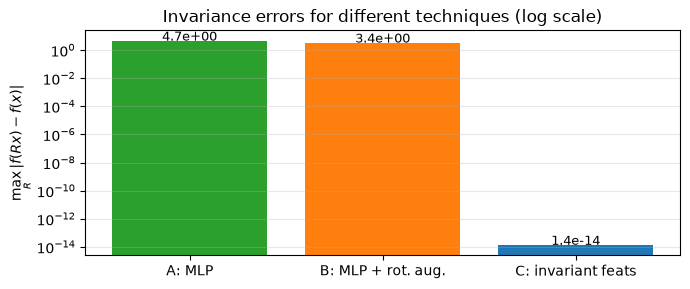

In [11]:
# Invariance error on a log scale: augmentation helps, but only
# invariance-by-construction reaches machine precision.
names = list(results)
inv_errs = [results[name][1] for name in names]

# Create a regular bar plot to visualize the invariance error for different models
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(names, inv_errs, color=["C2", "C1", "C0"])
ax.set_yscale("log")
ax.set_ylabel(r"$\max_R |f(Rx) - f(x)|$")
ax.set_title("Invariance errors for different techniques (log scale)")
for bar, v in zip(bars, inv_errs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.6, f"{v:.1e}", ha="center", va="bottom", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()


得到的训练和评估数据清楚地表明,数据增强确实有帮助:模型 B 在旋转下的泛化能力和不变性都优于 A。但请注意*量级*:即使我们把 B 的训练预算加倍(1000 步 vs. 500 步),其最坏情况下的不变性误差仍与普通 MLP 模型处于同一数量级。在这个例子中,对称性被*近似地学到*了,但从未被*施加*。要进一步压低误差,需要越来越多的数据和算力,而且永远不会降到零。相反,模型 C 即使在目标上*预测错误*的地方也是严格不变的:因为它使用不变特征(成对距离而非坐标),不变性内建于架构之中,而不在拟合的权重里。

对于标量目标,手工构造的不变特征(距离、角度)可以走得很远。这就是我们将在第 07 课中回顾的 SchNet/DimeNet 路线。但要预测*等变*输出(力、偶极矩,以及使现代势函数数据高效的内部向量/张量特征),我们需要输出在构造上就正确变换的层。这需要精确知道在这些情形下 "$D_Y(g)$" 可以是什么:**群表示**理论,正是下一课的内容!

## 总结

总结一下我们到目前为止学到的内容:

- 物理量在 $E(3)$ 下以规定的方式变换:能量是**不变的**,力/偶极矩是**等变**向量。
- $E(3)$ = 平移 + $O(3)$;$O(3) = SO(3) \times \{\mathbb{1}, P\}$(旋转 × 宇称);$SE(3)$ 去掉了反射。我们向你展示了如何数值地验证重要的群公理。
- 等变性是普遍的:$f(D_X(g)x) = D_Y(g)f(x)$;不变性是 $D_Y = \mathbb{1}$ 的特殊情形。
- 等变映射的复合仍是等变的:这是构建深度等变神经网络的通行证。
- 以坐标为输入的普通 MLP 不是不变的。旋转数据增强可以改善模型的精度和不变性,但不变性误差仍会停留在显著水平。另一方面,基于不变特征的模型在构造上就是不变的,即使在训练之前也严格不变。

**下一课:** [第 01b 课:群表示](01b_group_representations.ipynb):$D(g)$ 矩阵是什么、为什么它们可以分解成以 $l = 0, 1, 2, \dots$ 标记的*不可约*块,以及 e3nn 包如何计算它们(Wigner D 矩阵)。

## 练习

**1. 平移不变性(难度:🌶️):** 模型 C 使用了成对距离,因此它对*平移*也是严格不变的。测量模型 A、B、C 的平移不变性误差 $\max_t |f(x + t) - f(x)|$。哪些模型失败了?为什么旋转增强对平移没有帮助?

<details><summary>解答</summary>

```python
# Create a function to measure the translation invariance error
@torch.no_grad()
def translation_error(model, features, n=32):
    f0 = model(features(x_test)).squeeze(-1)
    return max((model(features(x_test + torch.randn(3))).squeeze(-1) - f0)
               .abs().max().item() for _ in range(n))

# Evaluate the translation invariance error for models A, B, and C
for name, (m, ft) in {"A": (model_A, flat), "B": (model_B, flat),
                      "C": (model_C, dists)}.items():
    print(name, f"{translation_error(m, ft):.3e}")
```

A 和 B 都严重失败:增强只用了旋转,没有任何东西教会 MLP 平移的性质。每种对称操作都必须独立地应用于数据做增强,而且每种都只能被近似地学到。模型 C 是精确的,因为成对距离与原点无关。 </details>

**2. 反射与手性(难度:🌶️🌶️):** 模型 B 只用*正常*旋转做了增强(`o3.rand_matrix` 的 $\det R = +1$)。测量它在反演 $x \mapsto -x$ 下的不变性误差,并将测试误差与课程中旋转情形的结果比较。目标 $y(x)$ 是反演不变的吗?

<details><summary>解答</summary>

```python
# Create a function to measure the inversion invariance error
@torch.no_grad()
def inversion_error(model, features):
    f0 = model(features(x_test)).squeeze(-1)
    return (model(features(-x_test)).squeeze(-1) - f0).abs().max().item()

# Evaluate the inversion invariance error for model B
print("B under inversion:", f"{inversion_error(model_B, flat):.3e}")
```

目标*是*反演不变的(距离在反演 $x \to -x$ 下不变),但反演下的误差明显大于旋转下的误差:模型从未见过反演过的点云。增强只覆盖你采样到的群元素/操作。(用 $O(3)$ 的语言说:B 是朝着 $SO(3)$ 不变性而非 $O(3)$ 不变性训练的。) </details>

**3. 纸笔练习:复合(难度:🌶️🌶️):** 设 $f: X \to Y$ 和 $h: Y \to Z$ 等变,即 $f(D_X(g)x) = D_Y(g)f(x)$ 和 $h(D_Y(g)y) = D_Z(g)h(y)$。证明复合 $h \circ f$ 等变,并由此得出结论:由等变层堆叠、最后一层不变的网络是端到端不变的。

<details><summary>解答</summary>

$h(f(D_X(g)x)) = h(D_Y(g) f(x)) = D_Z(g)\, h(f(x))$ —— 第一个等号用 $f$ 的等变性,第二个用 $h$ 在 $y = f(x)$ 处的等变性。由归纳法,任意有限层堆叠都是等变的;若最后一个映射的 $D_Z(g) = \mathbb{1}$(不变的读出,例如标量特征之和),则整个网络是不变的。 </details>

## 参考文献

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Thomas et al., *Tensor Field Networks* arXiv.1802.08219 (2018)](https://arxiv.org/pdf/1802.08219)